## load your dataset

In [1]:
import pandas as pd

df = pd.read_csv("house_price.csv")
df.head()


,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


## Basic EDA (Q1)

In [2]:
# Check shape
print("Dataset shape:", df.shape)

# Data types and missing values
print("\nInfo:")
print(df.info())

# Summary statistics
print("\nSummary:")
print(df.describe())

# Unique locations and sizes
print("\nUnique locations:", df['location'].nunique())
print("Unique sizes:", df['size'].nunique())


Dataset shape: (13200, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB
None

Summary:
         total_sqft          bath         price           bhk  price_per_sqft
count  13200.000000  13200.000000  13200.000000  13200.000000    1.320000e+04
mean    1555.302783      2.691136    112.276178      2.800833    7.920337e+03
std     1237.323445      1.338915    149.175995      1.292843    1.067272e+05
min        1.000000      1.000000      8.000000      1.000000  

## Detect and Remove Outliers (Q2)

### a) Mean ± Standard Deviation

In [3]:
mean = df['price_per_sqft'].mean()
std = df['price_per_sqft'].std()

# Keep rows within 1 standard deviation
df_mean_std = df[(df['price_per_sqft'] > (mean - std)) & (df['price_per_sqft'] < (mean + std))]
print("Remaining after Mean ± Std:", df_mean_std.shape)


Remaining after Mean ± Std: (13193, 7)


### b) Percentile Method (1st and 99th)

In [4]:
lower_percentile = df['price_per_sqft'].quantile(0.01)
upper_percentile = df['price_per_sqft'].quantile(0.99)

df_percentile = df[(df['price_per_sqft'] > lower_percentile) & (df['price_per_sqft'] < upper_percentile)]
print("Remaining after Percentile method:", df_percentile.shape)


Remaining after Percentile method: (12932, 7)


### c) IQR Method

In [5]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df[(df['price_per_sqft'] > (Q1 - 1.5 * IQR)) & (df['price_per_sqft'] < (Q3 + 1.5 * IQR))]
print("Remaining after IQR method:", df_iqr.shape)


Remaining after IQR method: (11935, 7)


### d) Z-Score Method

In [6]:
from scipy.stats import zscore

z_scores = zscore(df['price_per_sqft'])
df_z = df[(abs(z_scores) < 3)]
print("Remaining after Z-score method:", df_z.shape)


Remaining after Z-score method: (13195, 7)


## Box Plot Comparison (Q3)

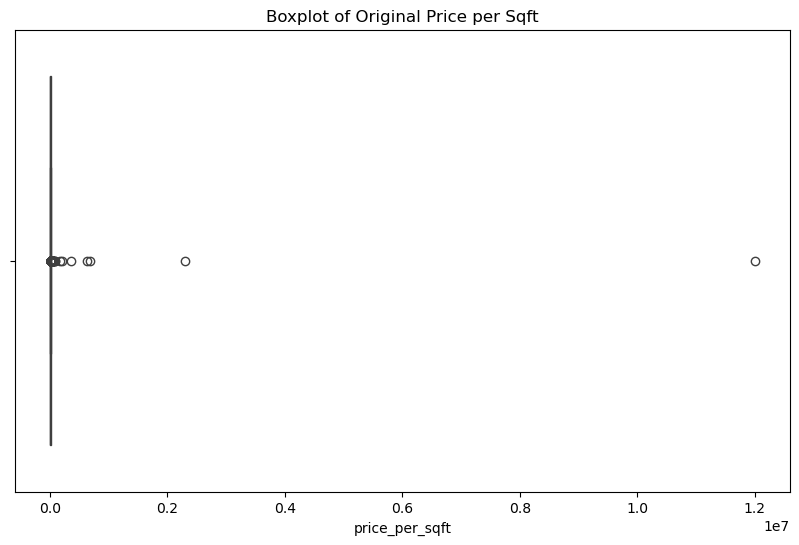

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare box plots
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price_per_sqft'])
plt.title("Boxplot of Original Price per Sqft")
plt.show()


### Mean ± Std:

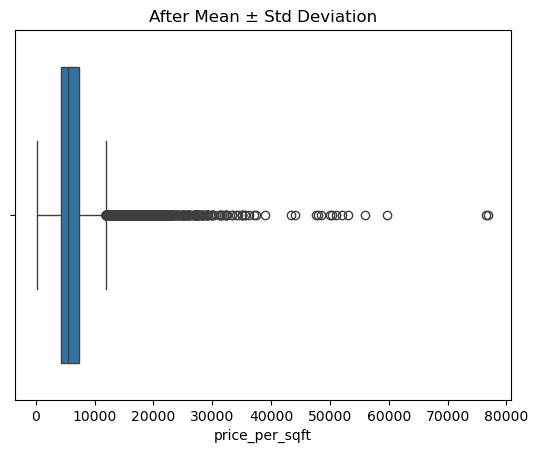

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_mean_std['price_per_sqft'])
plt.title("After Mean ± Std Deviation")
plt.show()



### Percentile Method 

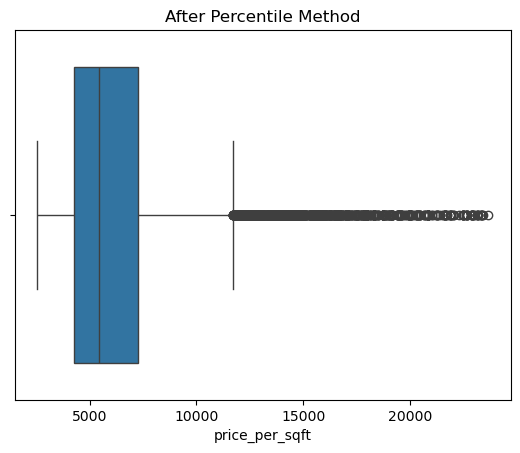

In [10]:
sns.boxplot(x=df_percentile['price_per_sqft'])
plt.title("After Percentile Method")
plt.show()


### IQR Method:

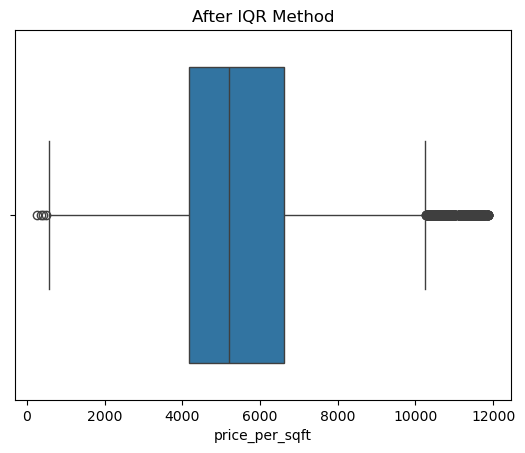

In [12]:
sns.boxplot(x=df_iqr['price_per_sqft'])
plt.title("After IQR Method")
plt.show()


### Z-Score Method

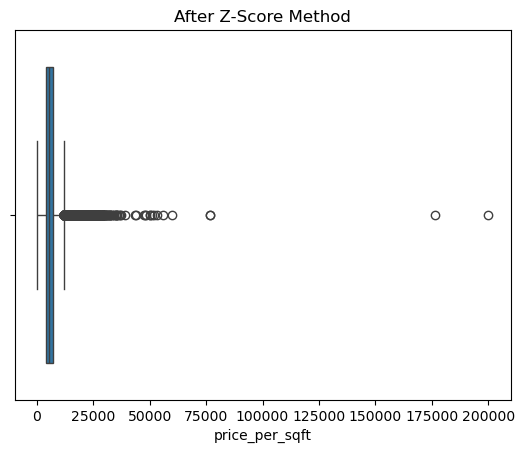

In [13]:
sns.boxplot(x=df_z['price_per_sqft'])
plt.title("After Z-Score Method")
plt.show()


## Histplot & Skew/Kurtosis (Q4)

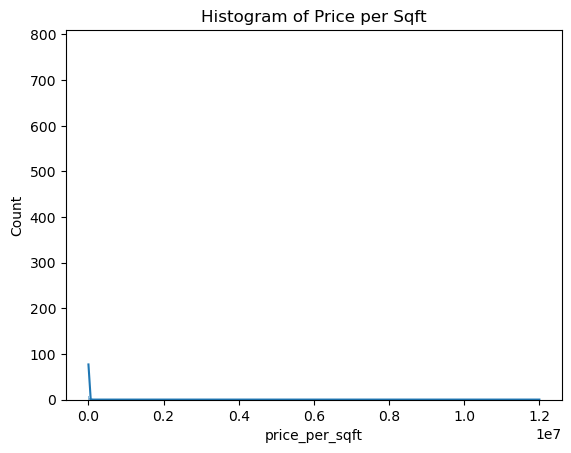

Skewness: 108.28105529705168
Kurtosis: 12095.21502832288


In [14]:
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Histogram of Price per Sqft")
plt.show()

# Skewness and Kurtosis
print("Skewness:", df['price_per_sqft'].skew())
print("Kurtosis:", df['price_per_sqft'].kurt())


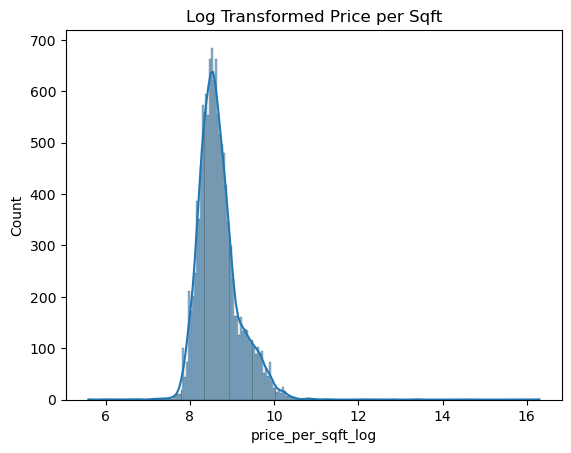

Skewness (log): 1.4004850530059296
Kurtosis (log): 9.206942162860814


In [15]:
import numpy as np
df['price_per_sqft_log'] = np.log1p(df['price_per_sqft'])

# Plot after transformation
sns.histplot(df['price_per_sqft_log'], kde=True)
plt.title("Log Transformed Price per Sqft")
plt.show()

# Skewness and kurtosis after transformation
print("Skewness (log):", df['price_per_sqft_log'].skew())
print("Kurtosis (log):", df['price_per_sqft_log'].kurt())


## Correlation & Heatmap (Q5)

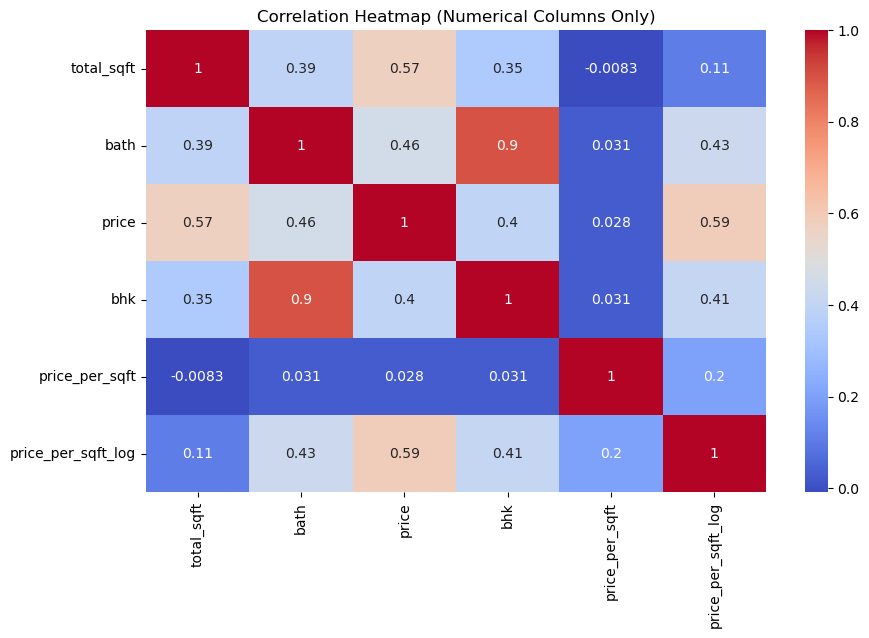

In [17]:
# Select only numeric columns
df_numeric = df.select_dtypes(include='number')

# Correlation matrix
corr_matrix = df_numeric.corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Columns Only)")
plt.show()


## Scatter Plots (Q6)

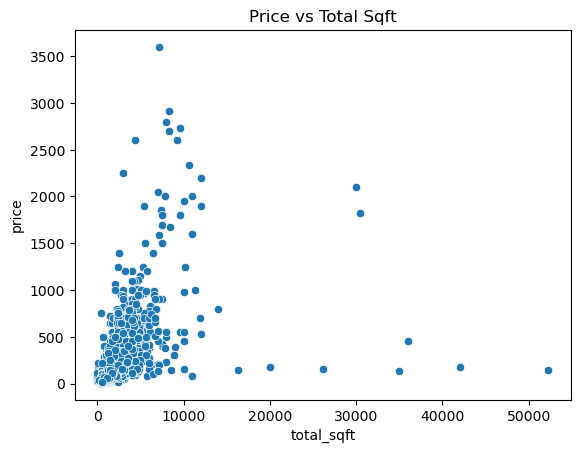

In [18]:
# Example scatter plot between price and total_sqft
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Price vs Total Sqft")
plt.show()
